In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [4]:
def inside_AABB(P, mins, maxs):
    return np.all(P >= mins) and np.all(P <= maxs)

In [5]:
def inside_cylinder(P, C0, D, h, r):
    v = P - C0
    t = np.dot(v, D)

    # height check
    if t < 0 or t > h:
        return False

    # radial distance
    radial = v - t * D
    return np.dot(radial, radial) <= r*r

In [6]:
def plot_points_and_box(points, inside_mask, box_corners):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # plot outside points
    ax.scatter(points[~inside_mask,0],
               points[~inside_mask,1],
               points[~inside_mask,2],
               s=1)

    # plot inside points
    ax.scatter(points[inside_mask,0],
               points[inside_mask,1],
               points[inside_mask,2],
               s=2, c='red')

    # plot box wireframe
    faces = [
        [box_corners[j] for j in [0,1,2,3]],
        [box_corners[j] for j in [4,5,6,7]],
        [box_corners[j] for j in [0,1,5,4]],
        [box_corners[j] for j in [2,3,7,6]],
        [box_corners[j] for j in [1,2,6,5]],
        [box_corners[j] for j in [4,7,3,0]],
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.2))

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

In [7]:
def plot_points_and_cylinder(points, inside_mask, C0, D, h, r, resolution=50):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # plot points
    ax.scatter(points[~inside_mask,0],
               points[~inside_mask,1],
               points[~inside_mask,2],
               s=1)
    ax.scatter(points[inside_mask,0],
               points[inside_mask,1],
               points[inside_mask,2],
               s=2, c='red')

    # Cylinder plotting
    theta = np.linspace(0, 2*np.pi, resolution)
    z = np.linspace(0, h, resolution)
    theta, z = np.meshgrid(theta, z)
    
    # Find two vectors orthogonal to D
    if abs(D[2]) < 0.99:
        # Pick a vector not parallel to D
        v = np.array([0,0,1])
    else:
        v = np.array([1,0,0])
    # First orthogonal vector
    U = np.cross(D, v)
    U = U / np.linalg.norm(U)
    # Second orthogonal vector
    V = np.cross(D, U)
    
    X = C0[0] + r*np.cos(theta)*U[0] + r*np.sin(theta)*V[0] + z*D[0]
    Y = C0[1] + r*np.cos(theta)*U[1] + r*np.sin(theta)*V[1] + z*D[1]
    Z = C0[2] + r*np.cos(theta)*U[2] + r*np.sin(theta)*V[2] + z*D[2]

    ax.plot_surface(X, Y, Z, alpha=0.2, color='gray')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

In [8]:
# Sample points
points = np.random.rand(1000, 3) * 10  # 1000 points in a 10x10x10 cube

# Define AABB
mins = np.array([2, 2, 2])
maxs = np.array([7, 7, 7])
box_corners = np.array([
    [mins[0], mins[1], mins[2]],
    [maxs[0], mins[1], mins[2]],
    [maxs[0], maxs[1], mins[2]],
    [mins[0], maxs[1], mins[2]],
    [mins[0], mins[1], maxs[2]],
    [maxs[0], mins[1], maxs[2]],
    [maxs[0], maxs[1], maxs[2]],
    [mins[0], maxs[1], maxs[2]],
])


In [9]:
# Check which points are inside the box
inside_mask = np.array([inside_AABB(p, mins, maxs) for p in points])

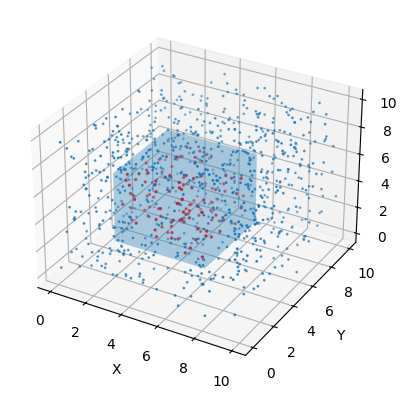

In [10]:
# Plot
plot_points_and_box(points, inside_mask, box_corners)

In [11]:
# --- Generate sample points ---
points = np.random.rand(1000, 3) * 10  # 1000 points in a 10x10x10 cube

# --- Cylinder parameters ---
C0 = np.array([5, 5, 2])       # base center of the cylinder
D = np.array([0, 0, 1])        # cylinder axis direction (normalized)
h = 5                          # height
r = 2                          # radius

# Make sure D is normalized
D = D / np.linalg.norm(D)

# --- Check which points are inside the cylinder ---
inside_cyl_mask = np.array([inside_cylinder(p, C0, D, h, r) for p in points])


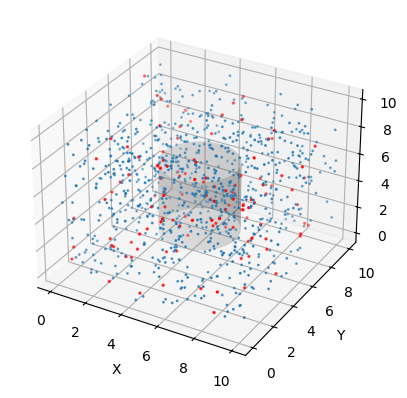

In [12]:

# --- Plot ---
plot_points_and_cylinder(points, inside_mask, C0, D, h, r)

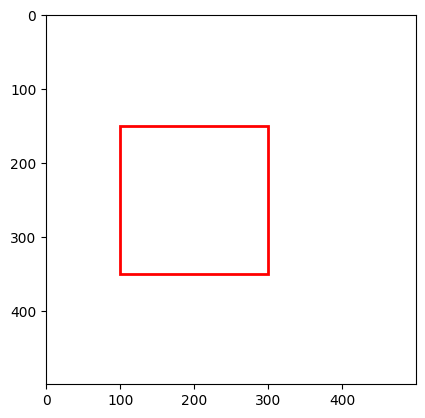

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2  # optional, if you want to read an image

# --- Load an image (optional) ---
# img = cv2.imread('image.jpg')          # OpenCV loads as BGR
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Or use a random image for demonstration
img = np.ones((500, 500, 3))  # white 500x500 image

# --- Define your AABB in pixel coordinates ---
# For 2D images, mins = top-left, maxs = bottom-right
mins = (100, 150)  # (x_min, y_min)
maxs = (300, 350)  # (x_max, y_max)

# --- Plot the image ---
fig, ax = plt.subplots()
ax.imshow(img)

# --- Add a rectangle overlay ---
width = maxs[0] - mins[0]
height = maxs[1] - mins[1]
rect = patches.Rectangle(mins, width, height, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)

plt.show()